## Explorative Analysis of Image Features with CNN

Both MLP and LR classifiers demonstrated excellent performance in identifying synthetic images (surprisingly with 100% accuracy), while both produced a significant number of false positives for synthetic labeling when given natural images. This motivated me to take an alternative perspective at the mechanism behind this behavior and identify possible image factors contributing to the "perfect accuracy" in identifying synthetic images. While it seems intuitive that synthetic images present distinctively different patterns than natural images, I hope to dive into the possibility of explaining those "obvious" differentiators on an algorithmic level instead of cognitive schema.

In the previously constructed PC space, fMRI responses demonstrated greater variability in PC1/PC2 of synthetic trials. Would it be possible to relate the top k principle components with specific image features? Or do they represent more complex vectors in the higher order neural space?

#### Objectives
- Use a pre-trained CNN to extract features from `nat` and `syn` images that were used in the experiment.
- Train a regression model to predict fMRI PC scores from CNN features in respective conditions.

#### Outputs
- Evaluation of how well image features predict fMRI responses, which would support/reject the hypothesis that the observed PCs reflect direct responses to specific features.
- (If identified) analyze which features are most predictive, especially for synthetic images. In contrast, what properties of features may explain the confusion for natural images?
- Use proper visualization to interpret results above.

## 1. Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image

# Check CUDA
cuda_available = torch.cuda.is_available()
print(f"CUDA Available: {cuda_available}")

if cuda_available:
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
    # Set device
    device = torch.device("cuda")
else:
    print("No CUDA-compatible GPU found. Using CPU.")
    device = torch.device("cpu")

CUDA Available: True
GPU: NVIDIA GeForce RTX 4070 Laptop GPU
CUDA Version: 13.0


In [2]:
# Random seeds
import random

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if cuda_available:
    torch.cuda.manual_seed_all(seed)

# Data paths
img_nat_dir = os.path.abspath(os.path.join("..", "img", "nat"))
img_syn_dir = os.path.abspath(os.path.join("..", "img", "syn"))

# Load and process images with ImageNet normalization
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def get_image_paths(img_dir):
    return [
        os.path.join(img_dir, fname) for fname in os.listdir(img_dir)
        if fname.lower().endswith(('.png'))
    ]

nat_image_paths = get_image_paths(img_nat_dir)
syn_image_paths = get_image_paths(img_syn_dir)

def process_images(img_paths, transform):
    images = []
    for path in img_paths:
        img = Image.open(path).convert('RGB')
        img_tensor = transform(img)
        images.append(img_tensor)
    return torch.stack(images)

nat_img_tensor = process_images(nat_image_paths, transform)
syn_img_tensor = process_images(syn_image_paths, transform)
print(f"Loaded {len(nat_img_tensor)} natural and {len(syn_img_tensor)} synthetic images.\n")


Loaded 1000 natural and 64 synthetic images.



## 2. Extract Features with Pre-trained ResNet18

In [3]:
# Remove final classification layer from ResNet-18
from torchvision.models import resnet18, ResNet18_Weights
resnet = resnet18(weights=ResNet18_Weights.DEFAULT)
resnet = resnet.to(device)
resnet.eval()
feature_extractor = nn.Sequential(*list(resnet.children())[:-1])

# Get features from the penultimate layer
def extract_features(img_tensor, batch_size=32):
    features = []
    with torch.no_grad():
        for batch in DataLoader(img_tensor, batch_size=batch_size):
            batch = batch.to(device)
            feature = feature_extractor(batch)
            feature = feature.view(feature.size(0), -1)
            features.append(feature.cpu().numpy())
    return np.concatenate(features, axis=0)

nat_features = extract_features(nat_img_tensor)
syn_features = extract_features(syn_img_tensor)
print(f"Extracted features: {nat_features.shape} (natural), {syn_features.shape} (synthetic)\n")
        

Extracted features: (1000, 512) (natural), (64, 512) (synthetic)



## 3. Visualize Features with PCA

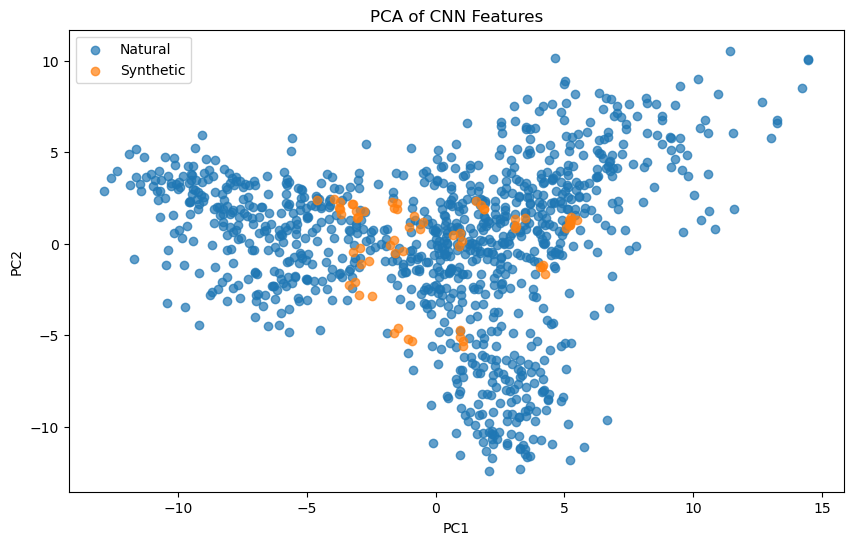

In [4]:
def pca(X, n_components=2):
    X_centered = X - np.mean(X, axis=0)
    cov = np.cov(X_centered, rowvar=False)
    eigvals, eigvecs = np.linalg.eigh(cov)
    idx = np.argsort(eigvals)[::-1][:n_components]
    eigvecs = eigvecs[:, idx]
    eigvals = eigvals[idx]
    X_pca = np.dot(X_centered, eigvecs[:, :n_components])
    return X_pca, eigvals, eigvecs

nat_pca, nat_eigvals, nat_eigvecs = pca(nat_features, n_components=2)
syn_pca, syn_eigvals, syn_eigvecs = pca(syn_features, n_components=2)

plt.figure(figsize=(10, 6))
plt.scatter(nat_pca[:, 0], nat_pca[:, 1], label="Natural", alpha=0.7)
plt.scatter(syn_pca[:, 0], syn_pca[:, 1], label="Synthetic", alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title("PCA of CNN Features")
plt.show()

#### Findings

The CNN PCA and fMRI PCA describe related but distinct spaces. The CNN PCA captures stimulus level structure, while the fMRI PCA captures neural response structure. In the CNN feature space, synthetic images occupy a narrower and more central region within the broader natural image manifold, suggesting lower visual diversity among synthetic stimuli. This provides a possible stimulus level explanation for the high synthetic decoding accuracy.

In fMRI response space, however, natural and synthetic trials show clearer separation, with synthetic responses shifted along a diagonal PC structure. This suggests that the synthetic condition may produce more consistent or more separable neural response patterns than expected from the first two CNN feature PCs alone. The result suggests that the neural classifier is likely using transformed, higher dimensional response structure, rejecting the hypothesis that fMRI responses are direct one-to-one reflection of low dimensional CNN PCA.

## 4. Encoder

In [14]:
# Align session 1 synthetic CNN features with fMRI PC arrays
# Process X_syn with PCA
X_syn = np.load(os.path.abspath(os.path.join("..", "outputs", "processed", "X_syn.npy")))
PCs = np.load(os.path.abspath(os.path.join("..", "outputs", "processed", "PCs.npy")))

X_syn_centered = X_syn - np.mean(X_syn, axis=0)
X_syn_pca = np.dot(X_syn_centered, PCs)

X_cnn = syn_features
X_cnn_mean = np.mean(X_cnn, axis=0)
X_cnn_std = np.std(X_cnn, axis=0)
X_cnn = (X_cnn - X_cnn_mean) / (X_cnn_std + 1e-8) # X

X_fmri = X_syn_pca[:64]
X_fmri_mean = np.mean(X_fmri, axis=0)
X_fmri_std = np.std(X_fmri, axis=0)
X_fmri = (X_fmri - X_fmri_mean) / (X_fmri_std + 1e-8) # Y

import torch.nn.functional as F

# Convert to PyTorch tensors
X = torch.tensor(X_cnn, dtype=torch.float32, device=device)
Y = torch.tensor(X_fmri, dtype=torch.float32, device=device)

# Split into training and testing sets
n = X.shape[0]
n_train = int(0.8 * n)
indices = torch.randperm(n)
X_train, Y_train = X[indices[:n_train]], Y[indices[:n_train]]
X_test, Y_test = X[indices[n_train:]], Y[indices[n_train:]]

#### (a) Linear Regression

In [48]:
# Linear regression model
class LR(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        return self.linear(x)

model = LR(X.shape[1], Y.shape[1]).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Train the model
n_epochs = 200
for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    Y_pred = model(X_train)
    loss = F.mse_loss(Y_pred, Y_train)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.4f}")
        
# Evaluate the model
model.eval()
with torch.no_grad():
    lr_Y_pred = model(X_test)
    lr_test_loss = F.mse_loss(lr_Y_pred, Y_test)
print(f"Test MSE Loss: {lr_test_loss.item():.4f}")

# Calculate R² score
def r2_score(Y_true, Y_pred):
    ss_res = torch.sum((Y_true - Y_pred) ** 2, dim=0)
    ss_tot = torch.sum((Y_true - Y_true.mean(dim=0)) ** 2, dim=0)
    return 1 - ss_res / ss_tot

lr_r2 = r2_score(Y_test, lr_Y_pred)
print("R² per PC:", lr_r2.cpu().numpy())
print("Mean R²:", lr_r2.mean().item())

lr_Y_pred_np = lr_Y_pred.cpu().numpy()
lr_Y_test_np = Y_test.cpu().numpy()

Epoch 50/200, Loss: 0.0164
Epoch 100/200, Loss: 0.0013
Epoch 150/200, Loss: 0.0002
Epoch 200/200, Loss: 0.0000
Test MSE Loss: 1.6062
R² per PC: [-3.4255333  -1.2553971  -3.3337631  -0.7346587  -0.62192416  0.47230327
 -0.02401865 -1.7804365  -0.5529498  -1.9383512   0.2789715  -0.02611899
 -0.9092506  -0.5943799  -0.800841    0.6378511   0.21349162 -0.01851261
  0.5425061   0.8393434  -0.9724628   0.6153778  -0.42285    -0.81203127
  0.37222975  0.552835    0.12398553  0.506949   -0.01614022 -0.6231086
 -0.14183342  0.1249786  -0.2914487  -0.20083964 -0.4790349  -0.6118325
 -1.0855131  -0.39263284 -1.1774397  -0.9535649  -0.08262146 -0.47688496
 -0.30388606 -0.3438995  -1.0788269   0.2940691  -0.762385   -0.49546027
 -0.31741226 -1.2802765  -0.56561327 -0.5325514  -0.8411714  -3.7479959
 -0.5302025  -0.90429246 -0.6502727  -0.5239563  -0.50463414 -0.6710018
 -1.9861362   0.23773664 -2.0341387  -0.70208037 -1.5140345  -1.4752622
 -0.14832294 -1.6454625   0.08489466 -0.51617324 -0.144998

#### (b) Ridge Regression

In [49]:
# Ridge regression model
ridge_lambda = 0.1

model = LR(X.shape[1], Y.shape[1]).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=ridge_lambda)

# Train the model
n_epochs = 200
for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    Y_pred = model(X_train)
    loss = F.mse_loss(Y_pred, Y_train)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.4f}")

# Evaluate the model
model.eval()
with torch.no_grad():
    rr_Y_pred = model(X_test)
    rr_test_loss = F.mse_loss(rr_Y_pred, Y_test)
print(f"Test MSE Loss: {rr_test_loss.item():.4f}")

rr_r2 = r2_score(Y_test, rr_Y_pred)
print("R² per PC:", rr_r2.cpu().numpy())
print("Mean R²:", rr_r2.mean().item())

rr_Y_pred_np = rr_Y_pred.cpu().numpy()
rr_Y_test_np = Y_test.cpu().numpy()

Epoch 50/200, Loss: 0.3316
Epoch 100/200, Loss: 0.3298
Epoch 150/200, Loss: 0.3298
Epoch 200/200, Loss: 0.3298
Test MSE Loss: 0.6933
R² per PC: [-0.40905142  0.18198198 -0.37739527  0.11826319  0.2320984   0.31405836
  0.29829365  0.0633167   0.19768506 -0.18677402  0.66929996  0.45657128
  0.2969725   0.36193162  0.40233225  0.70312166  0.58718455  0.5347701
  0.71549916  0.9152281   0.02512413  0.8197136   0.29589623  0.17838311
  0.7176846   0.7234665   0.6473143   0.5165746   0.3552202   0.2986977
  0.255531    0.52643067  0.50471294  0.30108798  0.70526636  0.3387236
  0.52581865  0.4048996   0.2645641   0.47101367  0.3715673   0.11456579
  0.16987127  0.15003234  0.08930027  0.52469754  0.1980964   0.15533262
  0.07455254 -0.13790381  0.47850996  0.29381013  0.4293669   0.49113804
 -0.06069946  0.15229315  0.06263369  0.3512324   0.09790772 -0.1338681
  0.3687533   0.48086143 -0.12021589 -0.15284193  0.19227058 -0.10691547
  0.47381985 -0.11364734  0.74854314  0.41401327  0.05782

#### (c) MLP for Nonlinearity

In [50]:
# MLP model
class MLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, output_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

model = MLP(X.shape[1], Y.shape[1]).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Train the model
n_epochs = 200
for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    Y_pred = model(X_train)
    loss = F.mse_loss(Y_pred, Y_train)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.4f}")

# Evaluate the model
model.eval()
with torch.no_grad():
    mlp_Y_pred = model(X_test)
    mlp_test_loss = F.mse_loss(mlp_Y_pred, Y_test)
print(f"Test MSE Loss: {mlp_test_loss.item():.4f}")

mlp_r2 = r2_score(Y_test, mlp_Y_pred)
print("R² per PC:", mlp_r2.cpu().numpy())
print("Mean R²:", mlp_r2.mean().item())

mlp_Y_pred_np = mlp_Y_pred.cpu().numpy()
mlp_Y_test_np = Y_test.cpu().numpy()

Epoch 50/200, Loss: 0.0289
Epoch 100/200, Loss: 0.0050
Epoch 150/200, Loss: 0.0034
Epoch 200/200, Loss: 0.0009
Test MSE Loss: 1.0092
R² per PC: [-2.1544464  -0.7584202  -1.4315236   0.09211665 -0.23751175  0.32683873
  0.61235267 -0.18542838 -0.29909885 -1.3677816   0.59131444  0.11832434
 -0.24007416 -0.01340115  0.3113534   0.63022816  0.53661746  0.28117722
  0.5991502   0.8857451  -0.06565452  0.75302345 -0.3355744  -0.6654768
  0.6416131   0.58704305  0.30017906  0.41624093  0.3639028   0.2041322
  0.16119981  0.44643486  0.20200121  0.04232854  0.3580404   0.30860806
 -0.20504606 -0.23176885 -0.4604007  -0.498829    0.47687346 -0.10270882
 -0.32884264 -0.3379469  -1.0631087   0.6363574   0.10137266  0.2792912
 -0.12066686 -0.89792275  0.32958704 -0.19675517  0.02956825 -0.10779953
 -0.46621323 -0.24378073 -0.03570926  0.23379898 -0.13275003 -0.30688357
  0.29224068  0.20133013 -0.6223     -0.503245   -0.6253656  -0.74943507
  0.4298212   0.2545743   0.54196244  0.19052756  0.0984

#### Encoder Performance Analysis

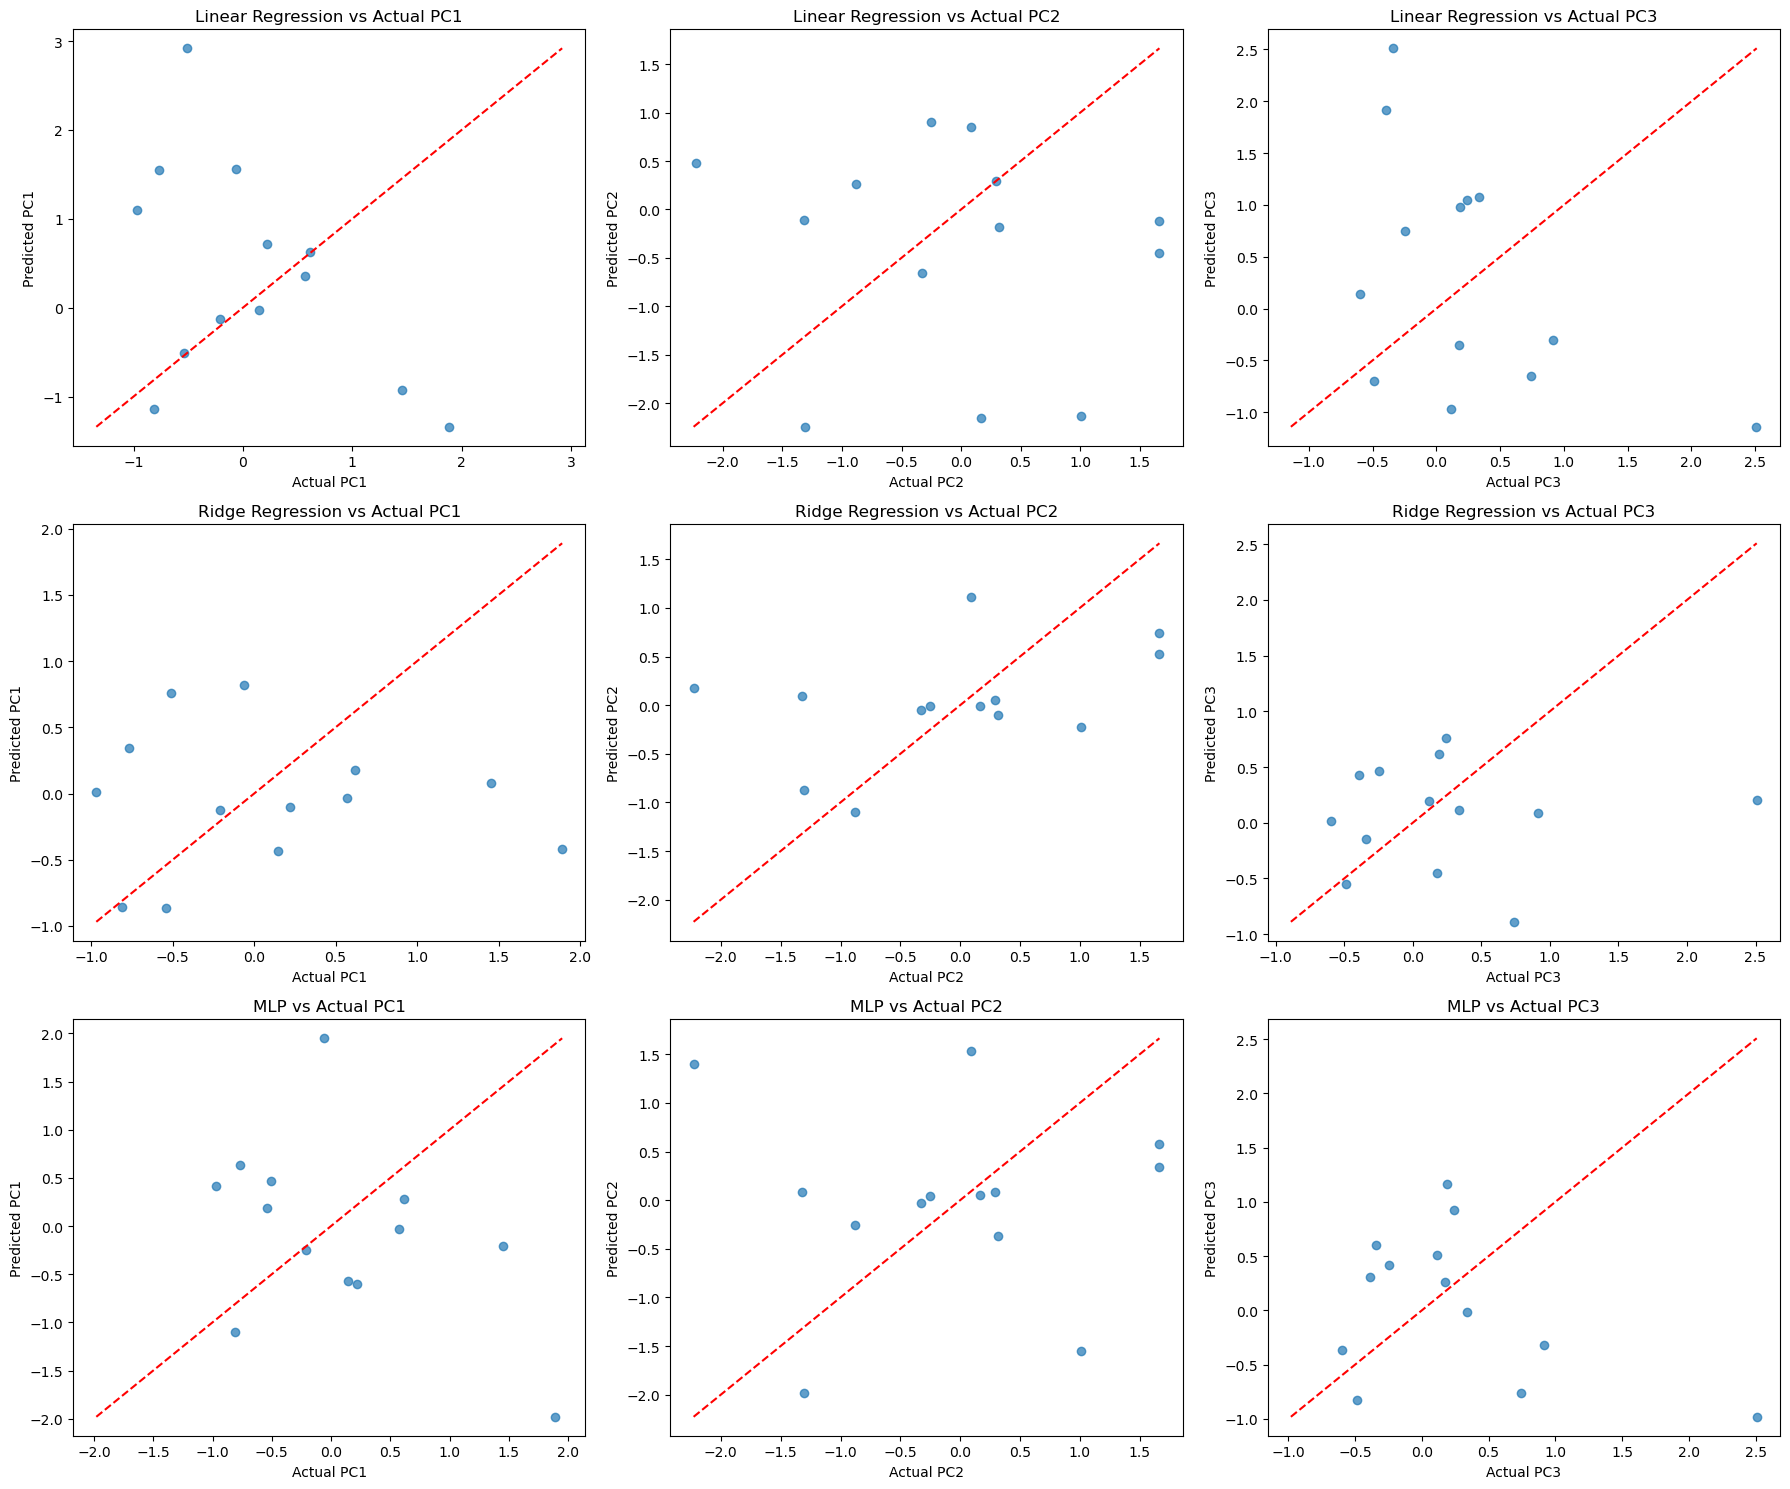

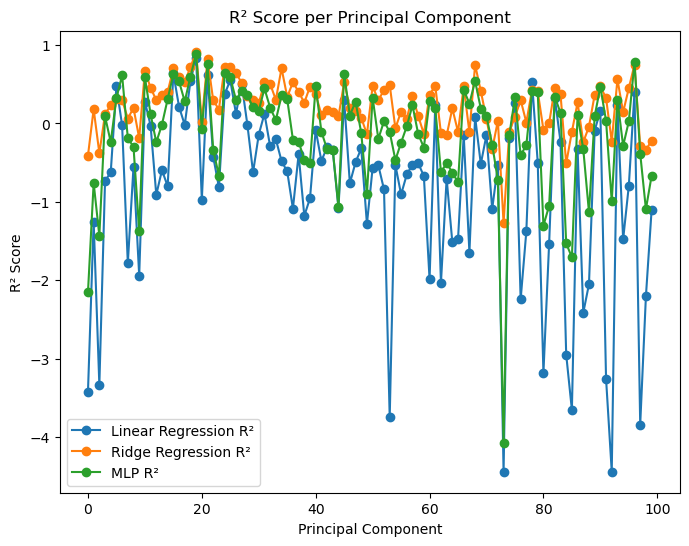

In [51]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
for pc in range(3):
    # Linear regression
    ax = axes[0, pc]
    ax.scatter(lr_Y_test_np[:, pc], lr_Y_pred_np[:, pc], alpha=0.7)
    ax.set_xlabel(f"Actual PC{pc+1}")
    ax.set_ylabel(f"Predicted PC{pc+1}")
    ax.set_title(f"Linear Regression vs Actual PC{pc+1}")
    min_val = min(lr_Y_test_np[:, pc].min(), lr_Y_pred_np[:, pc].min())
    max_val = max(lr_Y_test_np[:, pc].max(), lr_Y_pred_np[:, pc].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--')

    # Ridge regression
    ax = axes[1, pc]
    ax.scatter(rr_Y_test_np[:, pc], rr_Y_pred_np[:, pc], alpha=0.7)
    ax.set_xlabel(f"Actual PC{pc+1}")
    ax.set_ylabel(f"Predicted PC{pc+1}")
    ax.set_title(f"Ridge Regression vs Actual PC{pc+1}")
    min_val = min(rr_Y_test_np[:, pc].min(), rr_Y_pred_np[:, pc].min())
    max_val = max(rr_Y_test_np[:, pc].max(), rr_Y_pred_np[:, pc].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--')

    # MLP model
    ax = axes[2, pc]
    ax.scatter(mlp_Y_test_np[:, pc], mlp_Y_pred_np[:, pc], alpha=0.7)
    ax.set_xlabel(f"Actual PC{pc+1}")
    ax.set_ylabel(f"Predicted PC{pc+1}")
    ax.set_title(f"MLP vs Actual PC{pc+1}")
    min_val = min(mlp_Y_test_np[:, pc].min(), mlp_Y_pred_np[:, pc].min())
    max_val = max(mlp_Y_test_np[:, pc].max(), mlp_Y_pred_np[:, pc].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.tight_layout()
plt.show()

# R² bar plot
lr_r2 = r2_score(Y_test, lr_Y_pred).cpu().numpy()
rr_r2 = r2_score(Y_test, rr_Y_pred).cpu().numpy()
mlp_r2 = r2_score(Y_test, mlp_Y_pred).cpu().numpy()
plt.figure(figsize=(8, 6))
plt.plot(np.arange(len(lr_r2)), lr_r2, marker='o', label="Linear Regression R²")
plt.plot(np.arange(len(rr_r2)), rr_r2, marker='o', label="Ridge Regression R²")
plt.plot(np.arange(len(mlp_r2)), mlp_r2, marker='o', label="MLP R²")
plt.xlabel("Principal Component")
plt.ylabel("R² Score")
plt.title("R² Score per Principal Component")
plt.legend()
plt.show()

#### Findings
Comparison of the three linear/non-linear models elected Ridge Regression as the best approach for the encoder.

Across both decoding and encoding analyses, MLP was too flexible and always overfitted fMRI data.

While Ridge Regression is the only model achieving positive R^2 result, it still does not capture the full hidden transformation layer proposed earlier for exploration. In the future, better regularized mapping methods should be applied for more reliable prediction.